In [1]:
import numpy as np
import jax
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob
import sys
sys.path.append("/home/ihuarte/Escritorio/Ivan/NNs")

# os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")

from VA_project.model.model import J1J2Square
from VA_project.engine.runners import Runner

#from NN_utils import load_vstate
#from correlations import correlations_vstate

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print(jax.devices())

from NNs.NN_module.ST_utils import compare_params, masked_optimizer
from frozendict import deepfreeze

W0113 22:19:52.507620    8586 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0113 22:19:52.515800    8544 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

[CudaDevice(id=0)]


In [2]:
from NN_module.initialize_schedule import Schedule
setup = {
    "segments":[
       [ [50], [200], [500], [100]]
    ],
    
    "modes":[
        [ ["B"],["P"],["B"],["P"] ]
    ],
    "lr_struct":[

       [ [(0.3, 0.1)], [("linear(0.1, 0.01, 20)")], [("linear(0.1, 0.01)", "linear(0.1, 0.01, 10)")], [(0.01)] ]
    ],
    "repeat":[("E0e2", 2)],
    "rescale": 1
}
sch = Schedule(setup)

In [4]:
sch.build_schedule()
for period, info in sch.build_schedule():
    print(period)

[<generator object Schedule.generate_period.<locals>.<genexpr> at 0x718e7487c640>]


AssertionError: 2 or more lr instructions, but mode is P

In [ ]:
import jax.numpy as jnp

def exponential(epochs, y0, y1, steps=None):
    x = jnp.arange(epochs)

    if steps is None:
        # decay continuo
        return y0 * (y1 / y0) ** (x / epochs)

    k = (x * steps) // epochs
    k = jnp.minimum(k, steps - 1)

    return y0 * (y1 / y0) ** (k / steps)


epochs=100
steps = 7
y=exponential(epochs, 10, 1, steps=steps)

In [33]:
epochs=100
steps = 8
x = jnp.arange(epochs)
k = (x * steps) // epochs
k = jnp.minimum(k, steps - 1)
k

Array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7], dtype=int64)

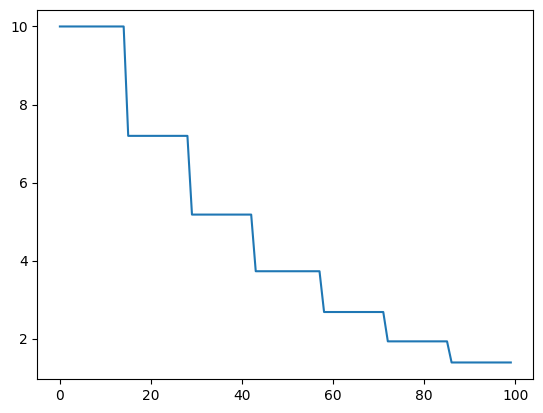

In [36]:
_, ax = plt.subplots()
ax.plot(range(epochs), y)

In [6]:
jnp.abs(
    0.7 * jax.random.normal(jax.random.PRNGKey(0), shape=(1000,))
).astype(jnp.int32)

Array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

In [2]:
%run ./Refine_simulation.py -a "/home/ihuarte/Escritorio/Ivan/NNs/new_pruebas/J1J2Square/CNN_Szabo_SplitTraining_CNN_CNNSzabo/Size_4x4/ST_20Px1_20Mx1_20Px1_20Mx1_20Px1_20Mx1_20Px1_20Mx1_20Px1_20Mx1/UUID_22f059e7/J1J2Square_CNN_Szabo_results_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0_date_20260112T162459_UUID_22f059e7.json"

[CpuDevice(id=0)]
Loading vstate


In [5]:
from NN_module.observables import print_max_contributors

# x =jnp.array([])
x_ED = np.loadtxt(artifact['_artifacts']['x_ED'], dtype=complex)
max_contr = print_max_contributors(x_ED,(4,4), N_max=100 ,return_states=True)

Config: 
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]
M = 0

Modulus: 0.16303087324094442
Phase: -0.6893334779258371

Config: 
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]
M = 0

Modulus: 0.16303087324094434
Phase: -0.689333477925838

Config: 
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1  1 -1  1]]
M = 0

Modulus: 0.08910950002973152
Phase: -0.6893334779258371

Config: 
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]
M = 0

Modulus: 0.08910950002973143
Phase: -0.689333477925838

Config: 
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]
M = 0

Modulus: 0.08910950002973142
Phase: -0.6893334779258371

Config: 
[[-1  1 -1  1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]
M = 0

Modulus: 0.08910950002973138
Phase: -0.6893334779258375

Config: 
[[ 1 -1 -1  1]
 [-1  1  1 -1]
 [ 1 -1 -1  1]
 [-1  1  1 -1]]
M = 0

Modulus: 0.08910950002973064
Phase: -0.689333477925838

Config: 
[[-1 -1  1  1]
 [ 1  1 -1 -1]
 [-1 -1  1  1]
 [ 1  1 -1 

In [ ]:
vstate.variables['params']['PhaseNet']
model = 
_ = model.init(jax.random.PRNGKey(0), jnp.ones((1,4,4,1)))
model.apply({'params': vstate.variables['params']['PhaseNet']['Conv_0']}, jnp.ones((1,4,4,1)))

Array([[[[ 1.15971256,  1.3590788 , -0.52903361, -0.13766727,
          -0.29855061,  0.45089716,  1.64703587,  1.02956115,
          -1.04261551,  0.78963896,  1.34375497, -0.14299029,
          -0.13844808, -0.8270264 ,  0.93067957,  1.53178799,
           1.9514113 ,  1.19612892,  0.97256911,  1.84982319,
          -0.27931758,  1.41978771, -1.37583909,  0.30771633,
           0.74005397,  0.53383143, -1.01442871, -1.6467026 ,
          -0.50112901, -1.92145186, -0.7111742 , -1.75332378,
           1.83489376,  1.05677164, -0.14234729,  1.76904172,
          -2.94489748, -0.30862535, -1.21013317,  0.29102649,
          -0.5217292 ,  1.39475116, -0.14948261, -0.13081453,
           0.27295945, -0.13638827, -0.3433289 ,  0.71696139,
          -1.19886403, -0.09576879],
         [ 1.15971256,  1.3590788 , -0.52903361, -0.13766727,
          -0.29855061,  0.45089716,  1.64703587,  1.02956115,
          -1.04261551,  0.78963896,  1.34375497, -0.14299029,
          -0.13844808, -0.8270264

In [3]:
size = [4,4]
N = int(jnp.prod(jnp.array(size)))
J1 = 1.0 ; J2 = 0.5
j1j2 = J1J2Square(size, J1, J2, bc='periodic', order='default_2')
# H = Runner(j1j2.cm, S_operators=True).build_hamiltonian()
hi = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=None)

N = 16
B = 3

In [4]:
neighbors = j1j2.cm.lattice.neighbors
nn_max = len(neighbors[0])
nn_dim = [len(neighbor) for neighbor in neighbors[0]]
max_per_shell = max(nn_dim)

neighbors_array = -jnp.ones((N, nn_max, max_per_shell), dtype=jnp.int32)

for i in range(N):
    for s in range(nn_max):
        neigh = neighbors[i][s]
        neighbors_array = neighbors_array.at[i, s, :len(neigh)].set(
            jnp.array(neigh)
        )


/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


In [5]:
key = jax.random.PRNGKey(int(time.time()))
(key1, key2, key3) = jax.random.split(key, (3,))

sigma = 0.9
n_samples = 3
σ = jnp.array([(-1) ** jnp.arange(N)] * n_samples)

# Select one spin per sample
s0 = jax.random.randint(key1, shape=(n_samples,), minval=0, maxval=N)

nn_rand = jnp.abs(sigma * jax.random.normal(key2, shape=(n_samples,))).astype(jnp.int32)
nn_rand = jnp.where(nn_rand < nn_max, nn_rand, nn_max - 1)


keys = jax.random.split(key, n_samples)
nn_dim = jnp.array(nn_dim, dtype=jnp.int32)
single_rand = lambda k, nn: jax.random.randint(k, (), 0, nn_dim[nn])
nn_at_rand = jax.vmap(single_rand)(keys, nn_rand)

s1 = neighbors_array[s0, nn_rand, nn_at_rand]

# Swap s0 and s1 values in each sample
mask_s0 = jnp.arange(N) == s0[:, None]
mask_s1 = jnp.arange(N) == s1[:, None]

vals_0 = jnp.take_along_axis(σ, indices=s0[:, None], axis=-1)
vals_1 = jnp.take_along_axis(σ, indices=s1[:, None], axis=-1)

σ_new = jnp.where(mask_s0, vals_1, jnp.where(mask_s1, vals_0, σ)).astype(
    jnp.int8
)

σ_new.reshape(-1,*size)

Array([[[ 1, -1,  1, -1],
        [ 1, -1,  1, -1],
        [ 1, -1,  1, -1],
        [ 1, -1,  1, -1]],

       [[ 1, -1,  1, -1],
        [ 1, -1, -1,  1],
        [ 1, -1,  1, -1],
        [ 1, -1,  1, -1]],

       [[ 1, -1,  1, -1],
        [ 1, -1,  1, -1],
        [ 1, -1,  1, -1],
        [ 1, -1, -1,  1]]], dtype=int8)

In [7]:
s0,s1



(Array([13,  7, 14], dtype=int64), Array([ 9,  6, 15], dtype=int32))

In [ ]:

nn_at_rand = nn_at_rand[jnp.arange(n_samples), nn_rand]
s1 = neighbors_array[s0, nn_rand, nn_at_rand]

# Swap s0 and s1 values in each sample
mask_s0 = jnp.arange(N) == s0[:, None]
mask_s1 = jnp.arange(N) == s1[:, None]

vals_0 = jnp.take_along_axis(σ, indices=s0[:, None], axis=-1)
vals_1 = jnp.take_along_axis(σ, indices=s1[:, None], axis=-1)

σ_new = jnp.where(mask_s0, vals_1, jnp.where(mask_s1, vals_0, σ)).astype(
    jnp.int8
)
nn_rand

In [ ]:
σ.reshape(-1,*size) 

In [ ]:
σ_new.reshape(-1,*size)


In [ ]:
print(s0)
print(nn_rand)
print(nn_at_rand)

In [ ]:
key = jax.random.PRNGKey(int(time.time()))
(key1, key2, key3) = jax.random.split(key, (3,))

while True:
    nn_rand = jnp.abs(sigma * jax.random.normal(key2, shape=(n_samples,)))
    nn_rand = jnp.where(nn_rand < nn_max, nn_rand, nn_max - 1)
    
    if any(nn_rand >= 3.0):
        print("Yes")

In [ ]:
from NN_module.NN_utils import traslations_2D

size = (4, 4)
token_size = None
irrep = (0, 0)
N = size[0] * size[1]
B = 2
worker = lambda x: x.mean(axis=-1)

x = jnp.array([jnp.arange(N)]*B)
x.shape

In [ ]:
na, nb = jnp.unravel_index(
    jnp.arange(size[0] * size[1]), size
)

characters = jnp.exp(
    2j
    * jnp.pi
    * (
        irrep[0] * na / size[0]
        + irrep[1] * nb / size[1]
    )
)
print("char: ", characters.shape)

# 2D traslation
traslational_x = traslations_2D(
    x, size=size, token_size=token_size, memory=False
)
print("traslational_x: ", traslational_x.shape)

ffw = jax.vmap(worker, in_axes=0)(traslational_x).T
print("ffw: ", ffw.shape)

symm_x = ffw * characters
print("symm_x: ", symm_x.shape)

symm_x = jnp.atleast_1d(symm_x.mean(axis=-1))
print("symm_x: ", symm_x.shape, "\n")

In [ ]:


symm_x = symm_x.mean(axis=0, keepdims=True)
print("symm_x: ", symm_x.shape, "\n")

In [ ]:
a = np.ones((4,3))
b = np.array([10,20,35])
c = a * b
c.mean(axis=-1)

In [ ]:
config = {
    "Traslation":{
        "on": True,
        "subgroup":[0,1]
    },
    "Z2":{
        "on":True
    }
}

dict((k, v) for k, v in config["Traslation"].items() if k not in ['on', 'subgroup'])

size = [4,4]
N = int(jnp.prod(jnp.array(size)))
J1 = 1.0 ; J2 = 0.5
j1j2 = J1J2Square(size, J1, J2, bc='periodic', order='default_2')
# H = Runner(j1j2.cm, S_operators=True).build_hamiltonian()
hi = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=None)

# configurations = hi.all_states()
# n_configurations = configurations.shape[0]
eng = Runner(j1j2.cm, S_operators=True)
eng.exact_energy_lanczos(hi)#/16

In [ ]:
j1j2.cm.lattice.neighbors

In [ ]:
irrep= (3,3)
nx, ny = jnp.unravel_index(
    jnp.arange( size[0] * size[1]), 
    size
)
for qa, qb in zip(nx, ny):
    print(qa, qb)
    characters = jnp.exp(
        2j * jnp.pi * (
            qa * nx / size[0] + qb * ny / size[1]
        )
    )
    print(characters)

    _, ax = plt.subplots(1,1)
    ax.scatter(characters.real, characters.imag, c=jnp.angle(characters), s=200)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    plt.show()

In [ ]:
def sign(x, anchors):

    phase = (
        2
        * jnp.pi
        * (
            irrep[0] * anchors[:, 0] / size[0]
            + irrep[1] * anchors[:, 1] / size[1]
        )
    )[:,None]
    print(phase.shape)
    log_modulus = x.real
    print(log_modulus.shape)
    new_phase = (x.imag + phase + jnp.pi) % (2 * jnp.pi) - jnp.pi
    print(new_phase.shape)

    return (log_modulus + 1j * new_phase).astype(x.dtype)

B =2
x = jnp.array([0.0 + 1.45j]*B)*jnp.pi
x = x[:,None]
print(x.shape)
anchors = jnp.array([[0,1]]*B)

(sign(x, anchors)/jnp.pi*180)

In [ ]:
jnp.exp(1j * jnp.pi/2)

In [ ]:
from Irreps.SymmBuilder import SymmGroup, _all_idx_combinations
import scipy as sp
group = SymmGroup(config, lattice_size=size)



In [ ]:
rep = group.get_unitary_representations(configurations)

In [ ]:
import jax.numpy.linalg as jla

def create_projector(q_a: int, q_b: int, z2_irrep: Z2_Irrep):
    "Create an unnormalized projection operator for a given irrep."
    if q_a < 0 or q_a >= N_A or q_b < 0 or q_b >= N_B:
        raise ValueError("q-point index out of range")
    # print(f"Carrete")
    

    nruter = jnp.zeros((n_configurations, n_configurations), dtype=complex)

    for n_trans_a in range(N_A):
        for n_trans_b in range(N_B):

            character = jnp.exp(
                -2.0j * jnp.pi * (q_a * n_trans_a / N_A + q_b * n_trans_b / N_B)
            )
            # print(f"(na, nb, nz) = ({n_trans_a, n_trans_b, 0})")
            # print(f"Character:{character}")
            # print("\n")
            operation_matrix = jla.matrix_power(
                translation_matrix_a, n_trans_a
            ) @ jla.matrix_power(translation_matrix_b, n_trans_b)
            nruter += character * operation_matrix
            if z2_irrep == 1:
                character *= -1.0
            # print(f"(na, nb, nz) = ({n_trans_a, n_trans_b, 1})")
            # print(f"Character:{character}")
            # print("\n")
            nruter += character * (operation_matrix @ inversion_matrix)


    return nruter

def get_irrep_projector(
    representations: jax.typing.ArrayLike,
    q_vector: list[int,],
    norm: bool = False
)-> jax.typing.ArrayLike:
    assert len(q_vector) == len(representations) == len(group.group)

    # print(f"MIO")

    dim = len(representations[0])
    nruter = jnp.zeros((dim, dim), dtype=jnp.complex128)

    for n_vector in _all_idx_combinations(group.N_group):

        character = group._character(q_vector, n_vector)
        nruter_2 = jnp.eye(dim)
        for i, representation in enumerate(representations):
            nruter_2 @= jla.matrix_power(representation, n_vector[i])
        # print(f"(na,nb,nz) = ({n_vector})")
        # print(f"Character:{character}")
        # print("\n")

        nruter += character * nruter_2

    # TODO: Implement dimension for non-abelian groups

    if norm:
        nruter /= group.norm

    return nruter

In [ ]:
P = {}
for q_vector in _all_idx_combinations(group.N_group):
    projector = group.get_irrep_projector(rep, q_vector, False)
    P[q_vector] = sp.linalg.orth(projector)



In [ ]:
H_dense = H.to_dense()
for irrep, Q in P.items():
    print(f"{irrep}: {Q.shape}")
    
    H_irrep = Q.T.conj() @ H_dense @ Q

    print(sp.linalg.eigh(H_irrep, eigvals_only=True, subset_by_index=[0,3]))

    print("\n")

In [ ]:
full_Q_basis = np.concatenate(list(P.values()), axis=1)
for irrep, Q in P.items():
    print(f"{irrep}: {Q.shape}")

    H_irrep = full_Q_basis.T.conj() @ H_dense @ full_Q_basis
    print(sp.linalg.eigh(H_irrep, eigvals_only=True, subset_by_index=[0,3]))

    print("\n")

In [ ]:

jnp.sum(projector@projector - projector), jnp.sum(projector_carrete@projector_carrete - projector_carrete)

In [ ]:

#### Calculo de norma media de gradientes por muestra
def tree_norm(tree, axis=None):
    """Norma L2 de PyTree"""
    def leaf_norm(leaf):
        return jnp.sqrt(jnp.sum(jnp.square(jnp.abs(leaf)), axis=axis or None))
    return jax.tree_util.tree_map(leaf_norm, tree)

# Norma por muestra (axis=1 para (Nsamples,...))
grad_norms_per_sample = tree_norm(O, axis=1) 

# Tomamos la norma por hoja de parametros
mean_norm_sample = jax.tree_util.tree_reduce(
    lambda x, y: x + y, 
    jax.tree_util.tree_map(jnp.mean, grad_norms_per_sample)
) / len(s_batch)

In [ ]:
#### Calculo de norma L2 global de gradientes ####
def tree_global_norm(tree):
    """Total L2 norm of a PyTree"""
    squares_sum = jax.tree_util.tree_map(lambda p: jnp.sum(jnp.square(jnp.abs(p))), tree)
    return jnp.sqrt(sum(jax.tree_util.tree_leaves(squares_sum)))

global_L2_norm = tree_global_norm(O) / jnp.sqrt(len(s_batch))

In [ ]:
def extract_real_imag(tree):
    """Extrae Re/Im de PyTree → DOS PyTrees separados"""
    def get_real(leaf):
        return leaf[:, 0]  # Solo Re
    
    def get_imag(leaf):
        return leaf[:, 1]  # Solo Im
    
    O_re = jax.tree_util.tree_map(get_real, tree)
    O_im = jax.tree_util.tree_map(get_imag, tree)
    return O_re, O_im

# 1. Extraer subredes
O_modulus = O['ModulusNet']
O_phase = O['PhaseNet']

O_mod_re, O_mod_im = extract_real_imag(O_modulus)
O_ph_re, O_ph_im  = extract_real_imag(O_phase)

# 2. Calcular normas Re/Im
norms_mod_re = tree_norm(O_mod_re, axis=0)  # Normas por muestra
norms_mod_im = tree_norm(O_mod_im, axis=0)
norms_ph_re  = tree_norm(O_ph_re, axis=0)
norms_ph_im  = tree_norm(O_ph_im, axis=0)


# Totales
mod_re_total = jax.tree_util.tree_reduce(lambda x,y:x+y, 
                                        jax.tree_util.tree_map(jnp.mean, norms_mod_re))
mod_im_total = jax.tree_util.tree_reduce(lambda x,y:x+y, 
                                        jax.tree_util.tree_map(jnp.mean, norms_mod_im))
ph_re_total  = jax.tree_util.tree_reduce(lambda x,y:x+y, 
                                        jax.tree_util.tree_map(jnp.mean, norms_ph_re))
ph_im_total  = jax.tree_util.tree_reduce(lambda x,y:x+y, 
                                        jax.tree_util.tree_map(jnp.mean, norms_ph_im))

print(f"Modulus Re: {mod_re_total:.2f}")
print(f"Modulus Im: {mod_im_total:.2f}")
print(f"Phase Re:  {ph_re_total:.2f}")
print(f"Phase Im:  {ph_im_total:.2f}")

In [ ]:
def percentage_above_threshold(norms_tree, threshold):
    """Calcula el porcentaje de gradientes por muestra que superan un umbral"""
    pct_tree = jax.tree_util.tree_map(
        lambda x: jnp.mean(x > threshold), norms_tree
    )
    total_pct = jax.tree_util.tree_reduce(lambda x,y: x+y, pct_tree)*100
    n_leaves = jax.tree_util.tree_structure(norms_tree).num_leaves
    return total_pct / n_leaves

def percentage_below_threshold(norms_tree, threshold):
    """Calcula el porcentaje de gradientes por muestra que están por debajo de un umbral"""
    pct_tree = jax.tree_util.tree_map(
        lambda x: jnp.mean(x < threshold), norms_tree
    )
    total_pct = jax.tree_util.tree_reduce(lambda x,y: x+y, pct_tree)*100
    n_leaves = jax.tree_util.tree_structure(norms_tree).num_leaves
    return total_pct / n_leaves

def sanity_check_grads_pytree(O):
    # 1. Norma media por muestra ⟨||∇logψ(s)||⟩
    grad_norms_sample = tree_norm(O, axis=1)
    total_norm_mean = jax.tree_util.tree_reduce(
        lambda x,y: x+y, jax.tree_util.tree_map(jnp.mean, grad_norms_sample)
    )
    
    # 2. Norma global ||∇global||
    global_norm = tree_global_norm(O)
    
    # 3. Stats Re/Im CORREGIDO ✓
    O_re, O_im = extract_real_imag(O)
    O_real_norm = tree_global_norm(O_re)
    O_imag_norm = tree_global_norm(O_im)
    
    # 4. % Explosivas
    threshold_points = jnp.logspace(-4, 3, num=8)
    per_above = list(map( lambda threshold: percentage_above_threshold(grad_norms_sample, threshold), threshold_points))
    per_below = [100 - per_above[0]]
    print(per_above)

    percentaje_per_norm = per_below + [per_above[i]-per_above[i+1] for i in range(len(per_above)-1)]
    print(percentaje_per_norm)

    # PRINTS
    print(f"⟨||∇logψ||⟩ = {total_norm_mean:.2e}")
    print(f"||∇global|| = {global_norm:.2e}")
    print(f"Re/Im ratio: {O_real_norm/O_imag_norm:.2f}")
    print(f"<1e-4: {100-per_above[0]:.3f}%\n")
    for i, thres in enumerate(threshold_points):
        if i != len(threshold_points)-1:    
            print(f"Interval {threshold_points[i]:.0e} <---> {threshold_points[i+1]:.0e}: {percentaje_per_norm[i+1]:.3f}%")
            print()


sanity_check_grads_pytree(O)

In [ ]:
### AUTOCORRELACION DE SAMPLES ###

driver = gs
vstate = driver.state
samples = vstate.samples  # (Nsamples, Nsites)
# Local energy
Eloc = vstate.local_estimators(gs._ham)
# Calcular estadísticas con autocorr
stats_eloc = nk.stats.statistics(Eloc.flatten())


Eloc_flat = Eloc.flatten()  # 2048 valores
N = Eloc_flat.shape[0]

stats = nk.stats.statistics(Eloc_flat)

if hasattr(stats, 'tau_corr_max'):
    tau_corr = stats.tau_corr_max if not np.isnan(stats.tau_corr_max) else stats.tau_corr
else:
    tau_corr = stats.tau_corr

ESS = N / (1 + 2 * tau_corr)
efficiency = ESS / N

print("=== SAMPLES AUTOCORRELATION ===")
print(f"Samples: {samples.shape}")
print(f"τ_corr = {stats.tau_corr:.3f} ")
print(f"ESS (Neff) = {ESS:.0f}/{N} ({efficiency:.3f})")


In [ ]:
fun = lambda q, n: jnp.exp(-1j* jnp.pi* q * n)
qn = ((0,0),(0,1),(1,0),(1,1))

for q, n in qn:
    print(fun(q,n))

In [ ]:

params = vstate.parameters
apply_fun = vstate._apply_fun
s_batch = vstate.samples.reshape(-1, vstate.hilbert.size)

def logpsi(p, s):
    return apply_fun({"params": p}, s)

grad_logpsi = jax.grad(lambda p, s: jnp.real(logpsi(p, s)))
grads = jax.vmap(lambda s: grad_logpsi(params, s))(s_batch)
grads_mean = jax.tree_util.tree_map(lambda g: jnp.mean(g, axis=0), grads)

report = {}

def analyze(g):
    return {
        "allclose_zero": jnp.allclose(g, 0.0, rtol=rtol, atol=atol),
        "has_nan": bool(jnp.isnan(g).any()),
        "has_inf": bool(jnp.isinf(g).any()),
        "max_abs": float(jnp.max(jnp.abs(g))),
    }

def recurse(tree, path=()):
    if isinstance(tree, dict):
        for k, v in tree.items():
            if k == branch:
                # Analizamos toda la subrama seleccionada
                report["/".join(path + (k,))] = jax.tree_util.tree_map(analyze, v)
            else:
                recurse(v, path + (k,))

recurse(grads_mean)

if not report:
    raise ValueError(f"No se encontró ninguna rama '{branch}' en los gradientes.")

all_zero, summary = summarize_report(report)

print("¿Toda la rama phase tiene gradientes ~0?", all_zero)
for path, stats in summary.items():
    print(path, stats)

In [ ]:
states=hi.all_states()
N=hi.size

bin_states=(-(states-1)/2).astype(jnp.int8)
bin_states = bin_states.T[::-1].T
powers = jnp.tile(jnp.arange(N), (bin_states.shape[0],1))

idx = jnp.sum(bin_states * 2**powers, axis=-1)

idx

In [ ]:

N = vstate.hilbert.size
samples = vstate.samples.reshape(-1,N)
bin_samples = (-(samples-1)/2).astype(jnp.int8)
bin_samples = bin_samples.T[::-1].T
powers = jnp.tile(jnp.arange(N), (bin_samples.shape[0],1))
samples_idx = jnp.sum(bin_samples * 2**powers, axis=-1)


In [ ]:
a=jnp.ones((3,4,8))

jnp.mean(a, axis=0).shape

In [ ]:
x = jnp.ones((1,16))
variables = model.init(jax.random.PRNGKey(0), x)
def collect_paths(tree, prefix=()):
    paths = []
    for k, v in tree.items():
        if isinstance(v, dict):
            paths.extend(collect_paths(v, prefix + (k,)))
        else:
            paths.append(prefix + (k,))
    return paths

# El árbol de parámetros (por ejemplo, 'params' de variables de Flax)
from flax.core import unfreeze
paths = collect_paths(unfreeze(variables['params']))

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from typing import Any

def build_flax_tree_graph(module: nn.Module, parent=None, graph=None):
    """
    Recorre los atributos tipo nn.Module y construye un árbol jerárquico.
    El nombre de cada nodo es 'Campo:Clase'.
    """
    if graph is None:
        graph = nx.DiGraph()
        root = type(module).__name__
        graph.add_node(root)
        parent = root

    for field in module.__dataclass_fields__:
        submod = getattr(module, field)
        if isinstance(submod, nn.Module):
            child_name = f"{field}:{type(submod).__name__}"
            graph.add_node(child_name)
            graph.add_edge(parent, child_name)
            build_flax_tree_graph(submod, parent=child_name, graph=graph)
        # Si el atributo es None, omitimos
    return graph

def plot_flax_tree(graph):
    # Usa layout jerárquico si tienes pydot y graphviz instalados, 
    # sino, usa un layout de fallback que sigue el orden topológico:
    try:
        pos = nx.nx_pydot.graphviz_layout(graph, prog='dot')
    except Exception:
        pos = nx.spring_layout(graph, seed=42)
    plt.figure(figsize=(13, 8))
    nx.draw(graph, pos, with_labels=True, node_size=2200, node_color="#aee", font_size=10, arrows=False)
    plt.title("Árbol jerárquico de módulos Flax")
    plt.show()

tree = build_flax_tree_graph(model)
plot_flax_tree(tree)

In [ ]:
def add_module_nodes(G, mod, parent_name):
    for field in mod.__dataclass_fields__:
        val = getattr(mod, field)
        if isinstance(val, nn.Module):
            child_name = parent_name + "." + field
            G.add_edge(parent_name, child_name)
            add_module_nodes(G, val, child_name)

G = nx.DiGraph()
root_name = type(model).__name__
G.add_node(root_name)
add_module_nodes(G, model, root_name)

plt.figure(figsize=(12,8))
nx.draw(G, with_labels=True, node_size=2000, font_size=8, node_color="orange")
plt.show()

In [ ]:
from NN_module.NN_utils import modphase
import itertools

def all_spin_configurations(N):
    # Genera todas las combinaciones posibles de N spines con valores ±1
    return jnp.array(list(itertools.product([-1, 1], repeat=N)))

def print_max_contributors(x, size, N_max=10):
    (mod, ph), _ = modphase(x)
    configs = all_spin_configurations(size[0]*size[1])

    idx = jnp.argsort(mod)[::-1][:N_max]
    max_configs = configs[idx,:]
    max_mods = mod[idx]
    max_phs = ph[idx]


    for config, mod, phs in zip(max_configs, max_mods, max_phs):
        print(f"Config: \n{config.reshape(size)}")
        print(f"\nModulus: {mod}")
        print(f"Phase: {phs}\n")


In [ ]:
print_max_contributors(x_ED, size=(4,4), N_max=20)

In [ ]:
ize=(4,4)
N_max=5
(mod, ph), _ = modphase(x_ED)
configs = all_spin_configurations(size[0]*size[1])

idx = jnp.argsort(mod)[::-N_max]
max_configs = configs[idx,:]
max_mods = mod[idx]
max_phs = ph[idx]

In [ ]:
idx = jnp.argsort(mod)[::-N_max]

In [ ]:
def logpsi(p, s):
    return apply_fun({"params": p}, s)

params = vstate.parameters
apply_fun = vstate._apply_fun
s_batch = vstate.samples.reshape(-1, vstate.hilbert.size)
s_batch = jnp.asarray(s_batch, dtype=jnp.complex128)
grad_logpsi = jax.grad(lambda p, s: logpsi(p, s), holomorphic=True)

#y, Jt = jax.vjp(lambda p, s: logpsi(p, s),params,s_batch)

grads = jax.vmap(lambda s: grad_logpsi(params, s))(s_batch)

In [ ]:
Jt(y)

In [ ]:
P0 = vs_0.parameters
P1 = vs_1.parameters

G0 = jax.vmap(lambda s: grad_logpsi(P0, s))(s_batch)
G1 = jax.vmap(lambda s: grad_logpsi(P1, s))(s_batch)

compare_params(G0, G1, atol=1e-20)

In [ ]:
transformations = {
    "train": optax.sgd(0.1),
    "freeze": optax.set_to_zero(),
}

grad_trans, tree_mask = masked_optimizer(P0, transformations, 'modulus')


In [ ]:
nk.jax.tree_cast()

In [ ]:
a = np.array([0, np.pi])
a.std()

In [ ]:
def energy(params, vstate):
    return vstate.expect(H).mean.real
grads = jax.grad(energy)(vstate.parameters, vstate)

In [ ]:
grads

In [ ]:
import sys
from pathlib import Path
sys.path.append(Path().resolve().parent.parent / "ATMOS_VA/VA_project/src")
from VA_project.model.model import J1J2Square
from VA_project.model.cm import HeisenbergXYZ
from VA_project.engine.runners import Runner

from NN_module.NN_utils import modphase

size=(4,4)
fields=[0.0,0.0,0.0]
kwargs_lattice={'bc':'periodic', 'order':'default_2'}
J1_list=np.linspace(-1,1,5)
J2_list=np.linspace(-1,1,5)

for J1 in J1_list:
    for J2 in J2_list:
        if J1==0.0 and J2==0.0:
            continue
        j1j2 = J1J2Square(size, J1, J2, fields, **kwargs_lattice)
        eng=Runner(j1j2.cm, S_operators=True)
        E_lanc = eng.exact_energy_lanczos(k = 100, eigenstates=False)

        fig, ax = plt.subplots()
        ax.set_title(f"J1-J2 model   J1:{J1}  J2:{J2}   size:{size[0]}x{size[1]}")
        ax.plot(range(len(E_lanc)), np.sort(E_lanc), marker='o', ms=1.2, color='r', label='Energy')
        ax.set_xlabel("Sorted eigenvalues")
        ax.set_ylabel(f"Energy")
        ax.grid()
        plt.tight_layout()
        plt.savefig(f"/home/ihuarte/Escritorio/Ivan/NNs/J1J2Spectra/Spctra_size_{size[0]}x{size[1]}_J1_{J1}_J2_{J2}.png",  dpi=600, bbox_inches="tight")


In [ ]:
idx = np.argsort(E_lanc)
E_lanc, x_lanc = E_lanc.T[idx][:e], x_lanc.T[:e]
#x_lanc = np.where(x_lanc>1e-13,x_lanc,0.0)
E_lanc, x_lanc 

In [ ]:
eig = np.linalg.eigh(H)
E_ed, x_ed = eig.eigenvalues[0:e],eig.eigenvectors.T[0:e]
E_ed, x_ed.shape

In [ ]:
mod_lanc = []
phase_lanc = []
mod_ed = []
phase_ed = []
stats_lanc = []
stats_ed = []
for x_E, x_L in zip(x_ed, x_lanc):
    assert len(x_E)==len(x_L)
    (mod_L, phase_L), stats_L = modphase(x_L)
    (mod_E, phase_E), stats_E = modphase(x_E)
    
    mod_lanc.append(mod_L)
    phase_lanc.append(mod_L)
    mod_ed.append(mod_E)
    phase_ed.append(phase_E)

    stats_lanc.append(stats_L)
    stats_ed.append(stats_E)




In [ ]:
title=r"J1:\;%.1f\quad J2:\;%.1f\qquad(%dx%d)"%(J1,J2,size[0],size[1])

In [ ]:
ms = 3

for mod_L, phase_L, stats_L, mod_E, phase_E, stats_E in zip(mod_lanc, phase_lanc, stats_lanc, mod_ed, phase_ed, stats_ed):
    fig,ax= plt.subplots(4,1, figsize=[20,15])

    ax[0].set_title(r"$Modulus\;and\;Phase\qquad %s$"%(title), fontsize=10)
    ax[0].set_xticks([])
    ax[0].set_ylabel(r"$Modulus$")
    ax[0].set_ylim(-0.00001,max(max(mod_E),max(mod_L))*9/8)
    ax[0].plot(mod_L, alpha=0.6, color='r', label=f"Lanczos")
    ax[0].plot(mod_E, alpha=0.6, label= f"ED")
    ax[0].legend()

    ax[1].set_xticks([])
    ax[1].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
    ax[1].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
    ax[1].set_ylabel(r"$Phase \;ED$")
    ax[1].set_ylim(-np.pi-0.1, np.pi+0.1)
    ax[1].plot(phase_E, alpha=0.15, ls='', marker='o', ms=ms, color='r', label='ED')
    ax[1].legend(loc='upper right')

    ax[2].set_xlabel(r"$C_i$")
    ax[2].set_ylabel(r"$Phase \;Lanczos$")
    ax[2].set_ylim(-np.pi-0.1, np.pi+0.1)
    ax[2].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
    ax[2].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
    ax[2].plot(phase_L, alpha=0.15, ls='', marker='o', ms=ms, label='Lanczos')
    ax[2].legend(loc='upper right')

    ax[3].set_xlabel(r"$Phase\;(radians)$")
    ax[3].set_ylabel(r"$Phase \;histogram$")
    ax[3].hist(phase_E, bins=500, range=(-np.pi, np.pi), color='r', density=True, alpha=0.9, label=f"ED  ({stats_E['type']})")
    ax[3].hist(phase_L, bins=500, range=(-np.pi, np.pi), color='b', density=True, alpha=0.7, label=f" ({stats_L['type']})")
    ax[3].text(0.8, 0.7, r"$\varphi_{ED}=%.2f \pm %.2f$"%(stats_E['phase']['mean'], stats_E['phase']['std']) + '\n' + r"$\varphi_{lanc}=%.2f \pm %.2f$"%(stats_L['phase']['mean'],stats_L['phase']['std']), 
                transform=ax[3].transAxes, fontsize=10,bbox=dict(facecolor="white", alpha=0.4))
    plt.show()
    plt.close()

In [ ]:
# Graficar histograma en coordenadas polares
counts_lanc, bin_edges = np.histogram(phase_E, bins= 500, range=(-np.pi, np.pi))
angles = (bin_edges[:-1] + bin_edges[1:]) /2

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, polar=True)
# ax.bar(angles, counts_lanc, width=2*np.pi/500, align="center", edgecolor="k")
ax.plot(angles, counts_lanc, color="darkblue", linewidth=2)
ax.fill_between(angles, 0, counts_lanc, color="skyblue", alpha=0.5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ejemplo: datos discretos (fases)
phases = np.random.choice(np.linspace(-np.pi, np.pi, 12), size=500, p=np.random.dirichlet(np.ones(12)))

# Convertir a [0, 2pi]
phases = (phases + 2*np.pi) % (2*np.pi)

# Bins
num_bins = 36
counts, bin_edges = np.histogram(phases, bins=num_bins, range=(0, 2*np.pi))

# Ángulos (centro de cada bin)
angles = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

bars = ax.bar(
    angles, counts,
    width=2*np.pi/num_bins, 
    align="center",
    edgecolor="white",      # bordes blancos
    linewidth=1.2,
    color=plt.cm.viridis(counts / counts.max()),  # colormap bonito
)

# Opciones estéticas
ax.set_theta_zero_location("E")  # 0° en el norte
ax.set_theta_direction(-1)       # ángulos en sentido horario
ax.grid(alpha=0.3)               # cuadrícula tenue
ax.set_xticklabels([])           # ocultar radios

plt.show()

plt.show()

In [ ]:
%run ./SplitTraining_LRM.py

In [ ]:
from NN_module.models.ST_modules.CvT3_EDPPh import CvT3_EDPPh
from NN_module.models.ST_modules.CvT3_CvT3 import CvT3_CvT3
from NN_module.models.CvT3 import CvT3

model = CvT3_CvT3(
        lattice_size=(4,4),
        n_CP_blocks_list_1=[2],
        CTemb_channels_list_1=[32],
        CP_channels_list_1=[32],
        attn_heads_list_1=[4],
        kernel_1=(3,3),
        final_architecture_1=(5,),
        n_CP_blocks_list_2=[2],
        CTemb_channels_list_2=[32],
        CP_channels_list_2=[32],
        attn_heads_list_2=[4],
        kernel_2=(3,3),
        final_architecture_2=(5,),
        phasors=True,
        symm_Z2=False,
        trivial_Z2=True,
)

# model= CvT3(
#     lattice_size=(4,4),
#     n_CP_blocks_list=[2],
#     CTemb_channels_list=[32],
#     CP_channels_list=[32],
#     attn_heads_list=[4],
#     kernel=(3,3),
#     final_architecture=(5,),
#     symm_Z2=False,
#     trivial_Z2=False,
#         )

# model= CvT3_EDPPh(
#     lattice_size=(4,4),
#     n_CP_blocks_list=[2],
#     CTemb_channels_list=[32],
#     CP_channels_list=[32],
#     attn_heads_list=[4],
#     kernel=(3,3),
#     final_architecture=(5,),
#     edpph_channels=64,
#     symm_Z2=False,
#     trivial_Z2=False,
#         )
    


In [ ]:
rng=jax.random.PRNGKey(676)
size=(4,4)
B=4

x = jax.random.choice(rng,jnp.array([1,-1]),(B,*size,1)).reshape(B,size[0]*size[1])
x_inv = -1 * x


In [ ]:
params = model.init(rng, x)

y=model.apply(params, x)
y_inv=model.apply(params, x_inv)


# y=jnp.array([y.real,y.imag])
# y_inv=jnp.array([y_inv.real,y_inv.imag])
delta_y = y-y_inv

In [ ]:
a, b = y.real, y.imag
c, d = y_inv.real, y_inv.imag
z = jnp.exp(y) + jnp.exp(y_inv)
jnp.log(z)

In [ ]:
print(y)
print(y_inv)
b=jnp.array([1,-1])[:,None]
jax.nn.logsumexp(jnp.array([y, y_inv]), b=b, axis=0)

In [ ]:
jnp.log(jnp.exp(y)+jnp.exp(y_inv))

In [ ]:
mod, phase = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/J1J2Square_SplitTraining_CvT3_CNNPhasor/Size_4x4/ST_25P25Mx6/J1J2Square_SplitTraining_CvT3_CNNPhasor_xED_4x4_J1J2_0.5_1.0_XYZ_0.0_0.0_0.0_modphase_xED.txt")

_, ax = plt.subplots()

ax.plot(mod)

In [ ]:
xed= np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/J1J2Square_SplitTraining_CvT3_CNNPhasor/Size_4x4/ST_25P25Mx6/J1J2Square_SplitTraining_CvT3_CNNPhasor_xED_4x4_J1J2_0.5_1.0_XYZ_0.0_0.0_0.0.txt", dtype=complex)
xed_filp = xed[::-1]


In [ ]:
def vmap_P_traslations(x, P_shifts):
    
    batched_traslations = lambda x, shift: jnp.roll(x, shift=shift, axis=(0,1))

    return jax.vmap(batched_traslations)(x, P_shifts)

def scan_P_traslations(x, P_shifts):

    def rollit(i, x_batch):
        x_b_trasl = jnp.roll(x_batch, shift=P_shifts[i], axis=(0,1))
        return i+1, x_b_trasl
    
    _, x_trasl = jax.lax.scan(rollit, init=0, xs=x)

    return x_trasl

def polyphase_components(x, strides):

    B, H, W, C = x.shape
    Hd, Wd = H // strides[0], W // strides[1], 
    xt = x.reshape(
        (B ,Hd ,strides[0],Wd,strides[1], C)
        ).transpose((0,1,3,4,2,5)).reshape(
            (B, Hd*Wd, *strides, C)
            ).transpose((0,3,2,1,4))

    shape = xt.shape
    poly_comp = xt.reshape(shape[0], shape[1]*shape[2], shape[3]*shape[4])

    return poly_comp

def get_maxnorm_indices(x, strides):
    """
    This function returns the traslation indices for a batched input of shape (B, H, W, C).
    It computes the polyphase components of a grid for each batch and channel, calculates 
    the L2 norm for each component and chooses the indices of the maximum value component.
    It works for both 1D and 2D inputs.
    Input:
        - x: (jnp.ArrayLike) Input data.
        - strides: (tuple) Strides for the next downsampling convolution.

    Returns:
        - x: Shifts (translations) for all batches and channels which makes the input 
             traslationaly equivariant.

    """
    _, H, W, _ = x.shape
    assert (H % strides[0]==0) & (W % strides[1]==0), f"`lattice_size` must be disible by `strides`. But they are {(H,W)} and {strides}"
    

    poly_comp = polyphase_components(x, strides)

    norm = jnp.linalg.norm(poly_comp, axis=-1)
    flat_idx = jnp.argmax(norm, axis=-1, keepdims=False)
    p, q = jnp.unravel_index(flat_idx, strides) 
    anchors = jnp.array([-p, -q]).T

    return anchors
     

def APS_equivariance_adapter(x, strides, mode = 'vmap'):

    P_shifts = get_maxnorm_indices(x, strides)

    if mode == 'scan':
        x = scan_P_traslations(x, P_shifts)
    elif mode == 'vmap':
        x = vmap_P_traslations(x, P_shifts)
    else:
        raise ValueError(f"No such mode: {mode}")

    return x






In [ ]:
x0 = jnp.zeros((1,4,4,1))
x0 = x0.at[0,1,0,0].set(10.0)  # activa un pixel en (1,0)

stride = (2,2)
shifts = get_maxnorm_indices(x0, stride)
print("shifts:", shifts)  # debería salir (-1,0)

x_hat = APS_equivariance_adapter(x0, stride)

In [ ]:
size = (8,8)
strides = (4,4)
assert (size[0] % strides[0]==0) & (size[1] % strides[1]==0), f"`lattice_size` must be disible by `strides`. But they are {size} and {strides}"
C = 1
B = 1

x = jnp.arange(size[0]*size[1]).reshape(*size)[None,:,:,None]
x = jnp.broadcast_to(x, (B, *size, C))


y = polyphase_equivariance_adapter(x, strides)
x.transpose((0,3,1,2)),y.transpose((0,3,1,2))

In [ ]:
x = jnp.zeros((1,8,8,3))
B, H, W, C = x.shape
strides=(2,2)
Hd, Wd = H // strides[0], W // strides[1]



# metemos valores grandes en la polifase (1,0)
coords = [(0,1), (0,3), (0,5), (0,7),
          (2,1), (2,3), (2,5), (2,7),
          (4,1), (4,3), (4,5), (4,7),
          (6,1), (6,3), (6,5), (6,7)]

for (i,j) in coords:
    x = x.at[0,i,j,:].set(7.0)

x.transpose((0,3,1,2))

In [ ]:
xt = x.reshape(
    (B ,Hd ,strides[0],Wd,strides[1], C)
    ).transpose((0,1,3,4,2,5)).reshape(
        (B, Hd*Wd, *strides, C)
        ).transpose((0,3,2,1,4))

shape = xt.shape
poly_comp = xt.reshape(shape[0], shape[1]*shape[2], shape[3]*shape[4])


In [ ]:
norm = jnp.linalg.norm(poly_comp, axis=-1)
flat_idx = jnp.argmax(norm, axis=-1)
p, q = jnp.unravel_index(flat_idx, strides) 
anchors =jnp.array([-p, -q]).T
anchors

In [ ]:
ST_setup={
    "segments":[[75,25],[50,50],[100]],
    "mode":[["P","M"], ["P","M"],["P"]],
    "repeat_segment":[5,4,1]
        }

raw_segments = [[seg]*rep for seg, rep in zip(ST_setup["segments"],ST_setup["repeat_segment"])]
segments = [seg for i in range(len(raw_segments)) for seg in raw_segments[i]]
raw_modes = [[mode]*rep for mode, rep in zip(ST_setup["mode"],ST_setup["repeat_segment"])]
modes = [seg for i in range(len(raw_segments)) for seg in raw_modes[i]]

segments = []
modes = []
s, m, r = ST_setup.values()
for seg, mode, repeats in zip(s,m,r):
    segments += [seg] * repeats
    modes += [mode] *repeats

segments, modes

In [ ]:
label = "ST"
s, m, r = ST_setup.values()
for seg, mode, repeats in zip(s, m, r):
    label += "_"
    for s, m in zip(seg, mode):
        label += f"{s}{m}"
    label += f"x{repeats}"

label

In [ ]:
B, H, W, C = x.shape
Hd, Wd = H // strides[0], W // strides[1], 
# print(f"(B, H, W, C) = {x.shape}")
# print(f"strides: {strides}")
# print(f"Hd, Wd = {Hd}, {Wd}")
x = x.reshape(
    (B, Wd, strides[1], Hd, strides[0], C),
    order='C').transpose((0, 1, 3, 2, 4, 5)
    ).reshape(B, Hd*Wd, *strides, C)
x.transpose(0,2,3,1,4)

In [ ]:
poly = polyphase_components(x, strides)
shape = poly.shape
poly = poly.reshape(*shape[0:-2], shape[-2]*shape[-1])

norm = jnp.linalg.norm(poly, axis=-1)
-jnp.argmax(norm, axis=-1)
